,date,item_id,price,sales_volume
0,2022-01-01,item_1,150.59,62
1,2022-01-01,item_2,435.62,20
2,2022-01-02,item_1,147.06,60
3,2022-01-02,item_2,454.16,16
4,2022-01-03,item_1,151.22,64


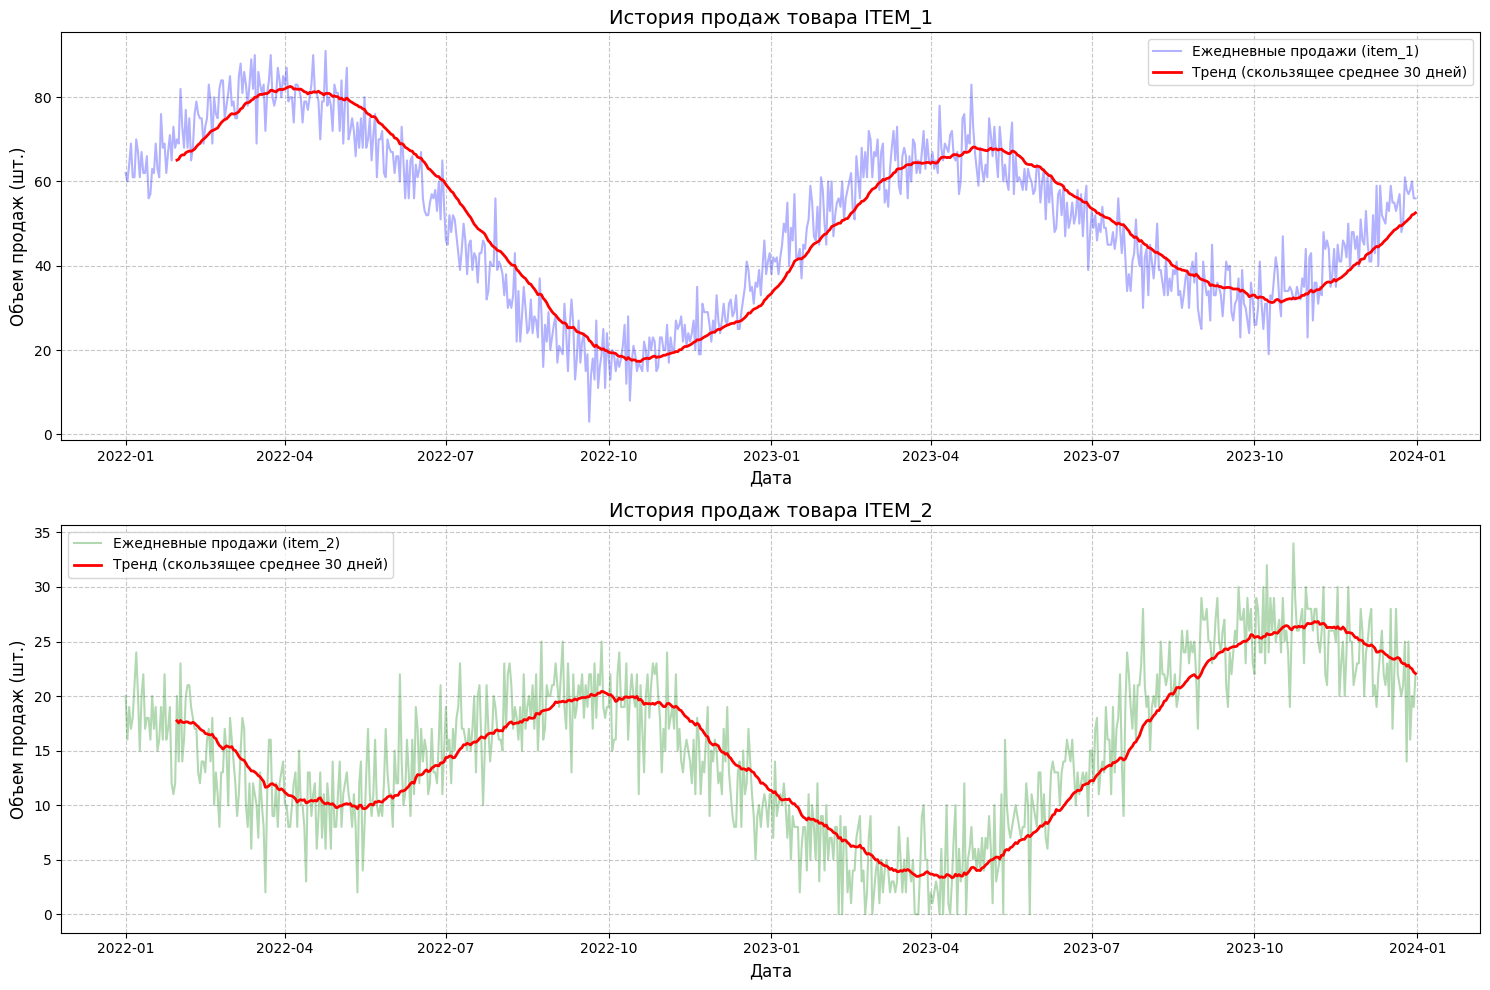

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загрузка сгенерированных данных
# Проверьте, что путь совпадает с тем, куда вы сохранили файл на прошлом шаге
df = pd.read_csv('../data/sales_history.csv', parse_dates=['date'])

# Выведем первые 5 строк, чтобы проверить загрузку
display(df.head())

# 2. Визуализация продаж во времени для ДВУХ товаров
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))

# Список наших товаров
items = ['item_1', 'item_2']
colors = ['blue', 'green']

for i, item in enumerate(items):
    # Фильтруем данные только для конкретного товара
    item_df = df[df['item_id'] == item].copy()

    # Считаем скользящее среднее (за 30 дней)
    item_df['rolling_mean'] = item_df['sales_volume'].rolling(window=30).mean()

    # Строим график фактических продаж (бледно)
    axes[i].plot(item_df['date'], item_df['sales_volume'],
                 label=f'Ежедневные продажи ({item})', color=colors[i], alpha=0.3)

    # Строим линию скользящего среднего (ярко)
    axes[i].plot(item_df['date'], item_df['rolling_mean'],
                 label='Тренд (скользящее среднее 30 дней)', color='red', linewidth=2)

    # Настройка красоты графика
    axes[i].set_title(f'История продаж товара {item.upper()}', fontsize=14)
    axes[i].set_xlabel('Дата', fontsize=12)
    axes[i].set_ylabel('Объем продаж (шт.)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend()

# Выравниваем графики, чтобы они не наезжали друг на друга
plt.tight_layout()

# Отображение
plt.show()